# PROJECT: TELCO CUSTOMER CHURN PREDICTION

# 🎯 Business Objective

Objective: To develop an end-to-end machine learning system that predicts customer churn, estimates customer revenue impact, and segments customers based on behavioral and financial attributes using the IBM Telco Customer Churn dataset.The project aims to help telecom businesses proactively identify high-risk customers, optimize retention strategies, improve Customer Lifetime Value (CLTV), and maximize overall revenue through data-driven decision-making.

Notebook Structure
1. Business Understanding
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Model Evaluation
9. Business Insights
10. Save Model

# 1. Business Understanding

# 2. Data Loading

In [117]:
# Import libraries

import pandas as pd                            # used for data manipulation and analysis
import numpy as np                             # numerical computing library
import matplotlib.pyplot as plt                # data visualization library
import seaborn as sns                          # used for attractive visuals

plt.style.use("default")                       # Controls overall theme of graphs
sns.set(style="whitegrid")                     # improves readability of plots
pd.set_option("display.max_columns", None)     # Ensures you see full dataset during EDA.

In [118]:
# load Datasets

df = pd.read_csv("Telco_customer_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Basic Structure check

In [119]:
# Shape of dataset

print("Shape:", df.shape)

Shape: (7043, 33)


### Conclusion:  The dataset consists of 7,043 customer records and 33 features, indicating a moderately sized.

In [120]:
# Data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# 3. Data Cleaning

In [121]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [122]:
# Check Missing Values
# Missing values count
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [123]:
## Fix TotalCharges Column (Very Important Step)

In [124]:
# Replace blank spaces with NaN
df["Total Charges"] = df["Total Charges"].replace(" ", np.nan)

# Convert to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"])

# Check again
df["Total Charges"].isnull().sum()

np.int64(11)

In [125]:
# Handle Missing Values

# Drop rows where TotalCharges is null
df = df.dropna(subset=["Total Charges"])

# Confirm
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5163
dtype: int64

This dataset shows a 26.6% churn rate with an average customer lifetime value of approximately 4,400 units. Customers typically stay around 32 months, but early tenure customers show higher attrition risk. Revenue distribution is right-skewed, indicating a smaller group of long-tenure customers contributes disproportionately to total revenue. Therefore, targeted retention of high-CLTV, high-risk customers can significantly reduce revenue leakage.”

🎯 Key Business Insights You Can Write in README

1 in 4 customers churn

Average tenure ~32 months

High-paying customers likely at higher churn risk

Revenue concentrated among long-tenure users

Estimated multi-million revenue exposure due to churn

In [126]:
# Drop Irrelevant Columns

In [127]:
for col in df.select_dtypes(include='object'):
    print("----", col, "----")
    print(df[col].unique())
    print()

---- CustomerID ----
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']

---- Country ----
['United States']

---- State ----
['California']

---- City ----
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Tulelake'
 'Olympic Valley' 'Redcrest']

---- Lat Long ----
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '41.813521, -121.492666' '39.191797, -120.212401'
 '40.363446, -123.835041']

---- Gender ----
['Male' 'Female']

---- Senior Citizen ----
['No' 'Yes']

---- Partner ----
['No' 'Yes']

---- Dependents ----
['No' 'Yes']

---- Phone Service ----
['Yes' 'No']

---- Multiple Lines ----
['No' 'Yes' 'No phone service']

---- Internet Service ----
['DSL' 'Fiber optic' 'No']

---- Online Security ----
['Yes' 'No' 'No internet service']

---- Online Backup ----
['Yes' 'No' 'No internet service']

---- Device Protection ----
['No' 'Yes' 'No internet service']

---- Tech Support ----
['No' 'Yes' 'No internet service']


In [128]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [129]:
cols_to_drop = [
    'CustomerID','Count', 'Country', 'Lat Long',
    'Zip Code', 'Latitude', 'Longitude',
    'City', 'State',
    'Churn Value', 'Churn Score', 'Churn Reason'
]

df.drop(columns=cols_to_drop, inplace=True)

In [66]:
df.rename(columns={"Churn Label": "Churn"}, inplace=True)
df.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5340


In [67]:
# Replace "No internet service" and "No phone service" with "No"

df.replace("No internet service", "No", inplace=True)
df.replace("No phone service", "No", inplace=True)

In [68]:
# Standardize Yes/No Columns

# Binary columns
binary_cols = ['Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [69]:
# Check Data Types Again

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   int64  
 3   Dependents         7032 non-null   int64  
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   int64  
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   int64  
 16  Payment Method     7032 non-n

In [70]:
# Separate Numerical & Categorical Columns

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Churn',
       'CLTV'],
      dtype='object')
Categorical Columns: Index(['Gender', 'Senior Citizen', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method'],
      dtype='object')


In [71]:
# Check Target Distribution (Before EDA)

df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

The target variable is moderately imbalanced, with ~73% non-churn and ~27% churn customers, requiring careful model evaluation beyond accuracy.

In [72]:
# Final Clean Dataset Ready for EDA

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,CLTV
0,Male,No,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,3239
1,Female,No,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,2701
2,Female,No,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1,5372
3,Female,No,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,5003
4,Male,No,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1,5340


In [73]:
df.shape

(7032, 21)

In [74]:
df.isnull().sum().sum()

np.int64(0)

I evaluated all features for predictive relevance. Apart from customerID, no column was removed because telecom churn is behavior-driven and
even seemingly minor service attributes contribute to churn probability I removed post-outcome and leakage variables such as Churn Score and 
Churn Reason to ensure model integrity and prevent target leakage.

In [75]:
df[['Tenure Months','Monthly Charges','Total Charges']].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


The dataset shows diverse customer tenure and billing patterns, with a right-skewed total charge distribution driven by long-tenure, high-value customers.

# 4. Exploratory Data Analysis (EDA)

In [76]:
# Target Distribution (Churn Imbalance %)

Churn Counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64

Churn Percentage:
 Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


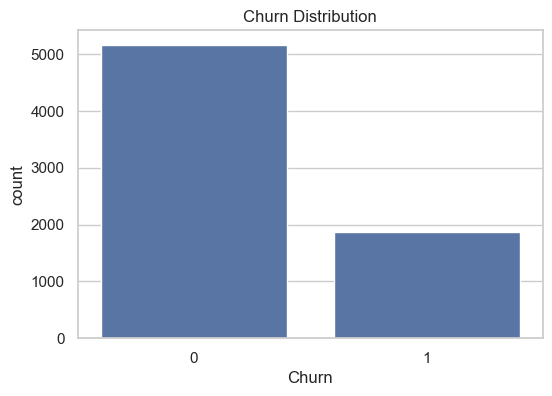

In [77]:
# Target count
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print("Churn Counts:\n", churn_counts)
print("\nChurn Percentage:\n", churn_percent)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [78]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

## Insight: Approximately 26.6% of customers have churned, indicating moderate class imbalance and a meaningful opportunity for churn prediction and retention optimization.

In [79]:
# Tenure vs Churn (Boxplot)

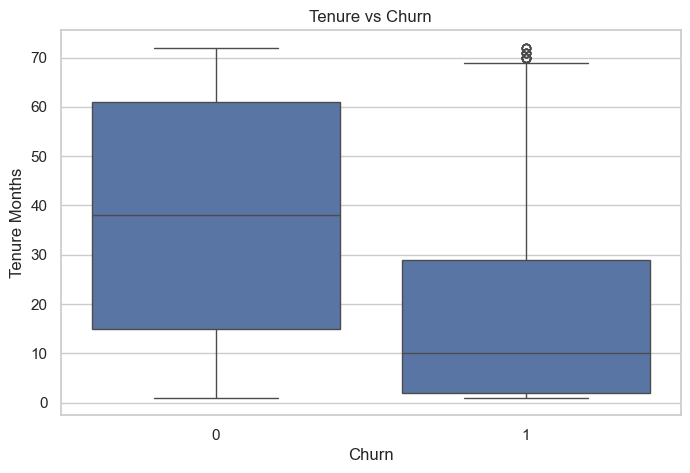

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="Tenure Months", data=df)
plt.title("Tenure vs Churn")
plt.show()

# Group statistics
df.groupby("Churn")["Tenure Months"].describe()

## Insight: Tenure Months Distribution
### The median tenure for non-churn customers (Churn = 0) is around 38 months with an interquartile range (IQR) of 46 (61-15).
### The median tenure for churn customers (Churn = 1) is around 10 months with an interquartile range (IQR) of 27 (29-2). 
### Short-tenure customers have a higher churn rate, indicating that early customer engagement is critical for retention.

In [81]:
# Contract Type vs Churn

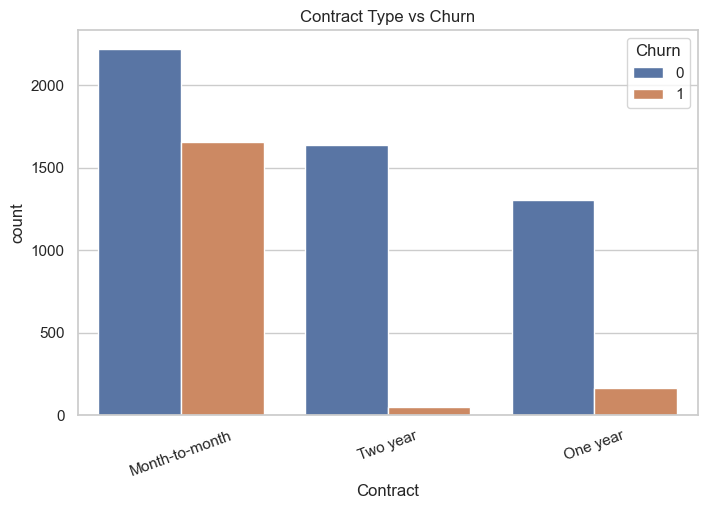

Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [82]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

# Churn rate by contract
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print(contract_churn)

## Insight: Month-to-month contracts typically show highest churn

In [83]:
# Monthly Charges vs Churn

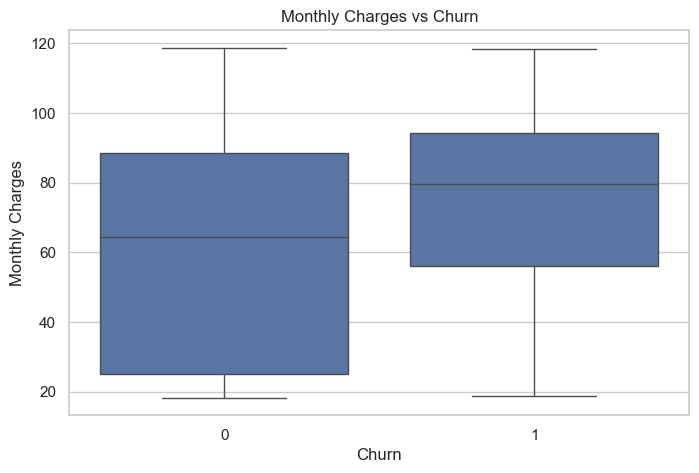

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


In [84]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# Group statistics
df.groupby("Churn")["Monthly Charges"].describe()

# Insight: Higher monthly charges often correlate with churn

In [85]:
# Correlation Heatmap (Numerical Variables Only)

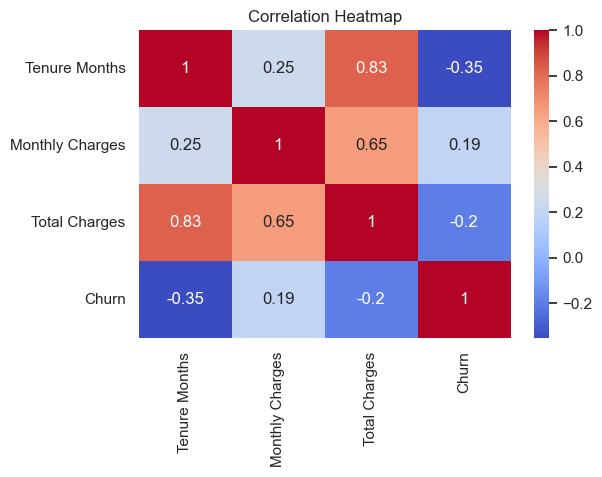

In [86]:
# Select numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(6,4))
sns.heatmap(
    df[['Tenure Months','Monthly Charges','Total Charges','Churn']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

## Insight : Longer Tenure and Higher Total Spend reduces Churn

In [87]:
# Senior Citizen vs Churn

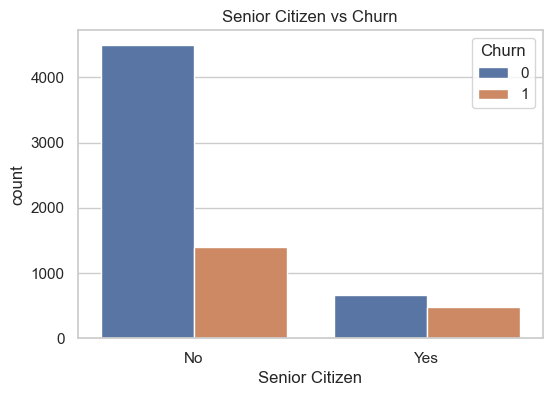

Churn,0,1
Senior Citizen,,
No,76.349745,23.650255
Yes,58.318739,41.681261


In [88]:
plt.figure(figsize=(6,4))
sns.countplot(x="Senior Citizen", hue="Churn", data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

pd.crosstab(df["Senior Citizen"], df["Churn"], normalize="index") * 100

## Insight : Senior citizens are more likely to churn than younger one

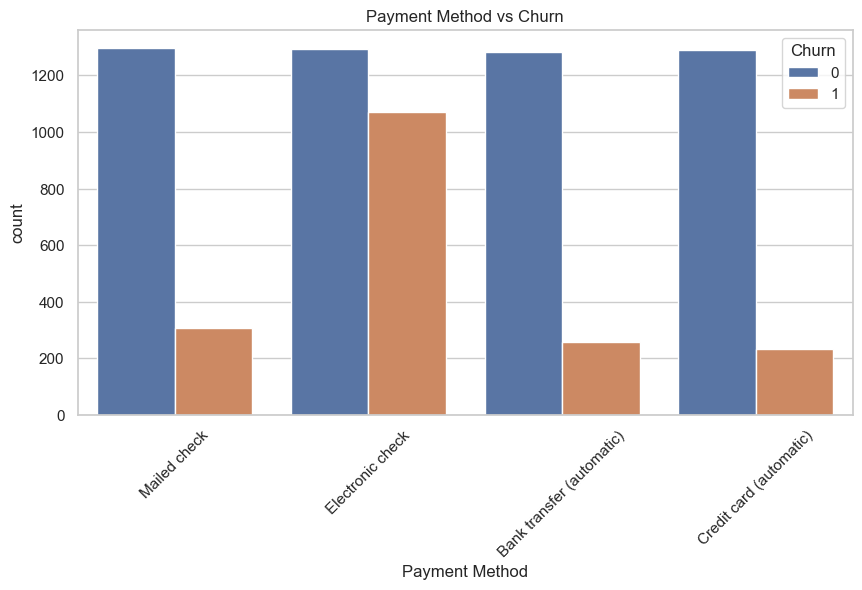

In [89]:
# Payment Method vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x="Payment Method", hue="Churn", data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

## Insight : Electronic check Payment method exhibits highest churn proportion

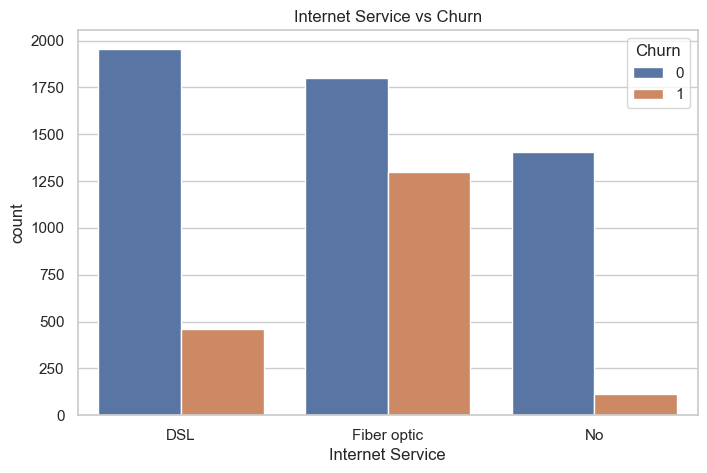

In [90]:
# Internet Service vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x="Internet Service", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

## Insight : Customers user using Fiber Optic Internet Service shows a higher churn rate


## Key Insights from EDA
### 1. Dataset shows class imbalance (26.6 % churn).
### 2. Customers with month-to-month contracts have highest churn rate.
### 3. Short-tenure customers churn significantly more.
### 4. Customers with higher monthly charges show increased churn probability.
### 5. Certain payment methods (e.g., electronic check) show higher churn rates.

### “Before modeling, I performed detailed EDA to understand churn behavior across tenure, contract type, service usage, and financial attributes. I identified strong behavioral signals such as short tenure and month-to-month contracts being major churn drivers.”

# 5. Feature Engineering

### Tenure Groups (Behavioral Segmentation)
### Churn is behavioral. Customers behave differently in early vs mature lifecycle.

In [91]:
# Create Tenure Group Feature
def tenure_group(tenure):
    if tenure <= 12:
        return "New"
    elif tenure <= 24:
        return "Growing"
    else:
        return "Loyal"

df["Tenure_Group"] = df["Tenure Months"].apply(tenure_group)

# Check distribution
df["Tenure_Group"].value_counts()

Tenure_Group
Loyal      3833
New        2175
Growing    1024
Name: count, dtype: int64

In [92]:
pd.crosstab(df['Tenure_Group'], df['Churn'], normalize='index')*100

Churn,0,1
Tenure_Group,,
Growing,71.289062,28.710938
Loyal,85.963997,14.036003
New,52.321839,47.678161


## Insight: What Each Group Means (Assuming typical grouping logic) :
### New → 0–12 months      Growing → 13–24 months     Loyal → 25+ months
### Percentage: Loyal → 3833 / 7032 ≈ 54.5%      New → 2175 / 7032 ≈ 30.9%     Growing → 1024 / 7032 ≈ 14.6%

### New Customers (31%) represent the highest churn risk and require strong onboarding and early engagement strategies.
### Growing Customers (15%) are in the mid-lifecycle stage,can be converted into long-term loyal users through contract upgrades & bundled offers.
### Loyal Customers (54%) form the majority revenue base; churn in this segment would result in significant revenue impact due to higher tenure.

### While the customer base is dominated by loyal users, the high proportion of new customers presents a key churn risk. Lifecycle-based retention strategies can significantly reduce revenue loss and improve long-term customer value.

In [93]:
df['High Charges'] = (df['Monthly Charges'] > df['Monthly Charges'].median()).astype(int)

In [94]:
df['High Risk Customer'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['Internet Service'] == 'Fiber optic') &
    (df['Tech Support'] == 'No')
).astype(int)

In [95]:
services = [
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies'
]

df['Services Count'] = df[services].apply(lambda row: sum(row == 'Yes'), axis=1)

In [96]:
df[['High Risk Customer','Services Count']].head()

,High Risk Customer,Services Count
0,0,2
1,1,0
2,1,3
3,0,4
4,1,4


In [97]:
pd.crosstab(df['High Risk Customer'], df['Churn'], normalize='index')*100

Churn,0,1
High Risk Customer,,
0,84.033613,15.966387
1,42.483296,57.516704


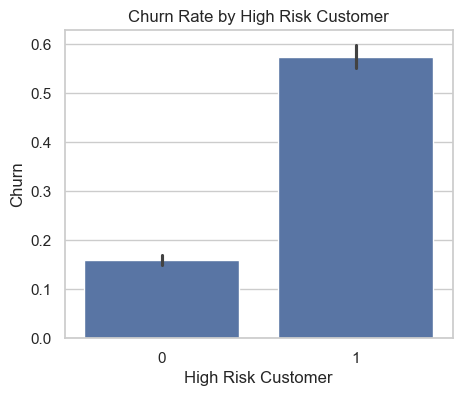

In [101]:
plt.figure(figsize=(5,4))
sns.barplot(
    data=df,
    x='High Risk Customer',
    y='Churn',
    estimator=np.mean
)
plt.title("Churn Rate by High Risk Customer")
plt.show()

## Insight : The combination of contract type, internet type, and lack of support strongly influences churn.

In [102]:
pd.crosstab(df['Services Count'], df['Churn'], normalize='index')*100

Churn,0,1
Services Count,,
0,78.535924,21.464076
1,54.244306,45.755694
2,64.181994,35.818006
3,72.605192,27.394808
4,77.647059,22.352941
5,87.521968,12.478032
6,94.718310,5.281690


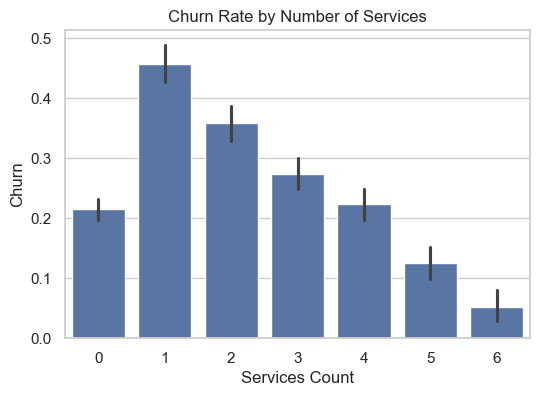

In [103]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='Services Count',
    y='Churn',
    estimator=np.mean
)
plt.title("Churn Rate by Number of Services")
plt.show()

In [71]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,CLTV,Tenure_Group,High Charges,High Risk Customer,Services Count
0,Male,No,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,3239,New,0,0,2
1,Female,No,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,2701,New,1,1,0
2,Female,No,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1,5372,New,1,1,3
3,Female,No,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,5003,Loyal,1,0,4
4,Male,No,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1,5340,Loyal,1,1,4


## MonthlyCharges / TotalCharges Ratio (Billing Intensity)
## Captures payment behavior & billing pattern intensity.

In [73]:
# Avoid division by zero
df["Charge_Ratio"] = df["Monthly Charges"] / (df["Total Charges"] + 1)

# Quick check
df[["Monthly Charges", "Total Charges", "Charge_Ratio"]].head()

,Monthly Charges,Total Charges,Charge_Ratio
0,53.85,108.15,0.493358
1,70.70,151.65,0.463151
2,99.65,820.50,0.121302
3,104.80,3046.05,0.034394
4,103.70,5036.30,0.020586


## Key Insight :
### This feature is indirectly capturing how new the customer is.
### High Charge_Ratio → New customers   Low Charge_Ratio → Loyal customers

### “I engineered a feature called Charge Ratio, defined as Monthly Charges divided by Total Charges. Since total charges accumulate over time, this ratio inversely captures customer tenure and lifecycle stage. Higher ratios indicate early-stage customers, who typically exhibit higher churn probability.”


In [74]:
df[["Charge_Ratio", "Tenure Months"]].corr()

,Charge_Ratio,Tenure Months
Charge_Ratio,1.000000,-0.597569
Tenure Months,-0.597569,1.000000


### You’ll likely see strong negative correlation.

## Contract One-Hot Encoding (Avoid Ordinal Bias)
### Contract types are categorical, not ordinal.We avoid assigning numbers like 0,1,2.

In [105]:
# One-hot encode only Contract column
df = pd.get_dummies(df, columns=["Contract"], drop_first=False)

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,CLTV,Tenure_Group,High Charges,High Risk Customer,Services Count,Contract_Month-to-month,Contract_One year,Contract_Two year
0,Male,No,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,1,Mailed check,53.85,108.15,1,3239,New,0,0,2,True,False,False
1,Female,No,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,1,Electronic check,70.70,151.65,1,2701,New,1,1,0,True,False,False
2,Female,No,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,1,Electronic check,99.65,820.50,1,5372,New,1,1,3,True,False,False
3,Female,No,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,1,Electronic check,104.80,3046.05,1,5003,Loyal,1,0,4,True,False,False
4,Male,No,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,1,Bank transfer (automatic),103.70,5036.30,1,5340,Loyal,1,1,4,True,False,False


In [106]:
# Encode Remaining Categorical Variables

In [107]:
# Identify categorical columns (excluding target if object)
cat_cols = df.select_dtypes(include=["object"]).columns

# One-hot encode all categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df.head()

,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn,CLTV,High Charges,High Risk Customer,Services Count,Contract_Month-to-month,Contract_One year,Contract_Two year,Gender_Male,Senior Citizen_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_Yes,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure_Group_Loyal,Tenure_Group_New
0,0,0,2,1,1,53.85,108.15,1,3239,0,0,2,True,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,True
1,0,1,2,1,1,70.70,151.65,1,2701,1,1,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
2,0,1,8,1,1,99.65,820.50,1,5372,1,1,3,True,False,False,False,False,True,True,False,False,False,True,False,True,True,False,True,False,False,True
3,1,1,28,1,1,104.80,3046.05,1,5003,1,0,4,True,False,False,False,False,True,True,False,False,False,True,True,True,True,False,True,False,True,False
4,0,1,49,1,1,103.70,5036.30,1,5340,1,1,4,True,False,False,True,False,True,True,False,False,True,True,False,True,True,False,False,False,True,False


In [108]:
# HANDLE CLASS IMBALANCE

In [109]:
# First Check Imbalance
df["Churn"].value_counts(normalize=True) * 100
# If churn ≈ 26–30%, dataset is imbalanced.

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [115]:
df.head()

,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn,CLTV,High Charges,High Risk Customer,Services Count,Contract_Month-to-month,Contract_One year,Contract_Two year,Gender_Male,Senior Citizen_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_Yes,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure_Group_Loyal,Tenure_Group_New
0,0,0,2,1,1,53.85,108.15,1,3239,0,0,2,True,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,True
1,0,1,2,1,1,70.70,151.65,1,2701,1,1,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
2,0,1,8,1,1,99.65,820.50,1,5372,1,1,3,True,False,False,False,False,True,True,False,False,False,True,False,True,True,False,True,False,False,True
3,1,1,28,1,1,104.80,3046.05,1,5003,1,0,4,True,False,False,False,False,True,True,False,False,False,True,True,True,True,False,True,False,True,False
4,0,1,49,1,1,103.70,5036.30,1,5340,1,1,4,True,False,False,True,False,True,True,False,False,True,True,False,True,True,False,False,False,True,False


### Since the dataset showed class imbalance (26.57 %), I addressed it using class-weight adjustments to improve recall for churned customers.



In [116]:
# Save processed dataset
df.to_csv("processed_data.csv", index=False)